In [1]:
import sys
from pathlib import Path

sys.path.append("../")
from src.components.classification.cls_data_ingestion import ClsDataIngestion
from src.components.classification.cls_data_transform import ClsDataTransformation
from src.components.classification.cls_model import ClassifierModel
from src.entity.cls_entity import ClsDataIngestionConfig, ClsTransformationConfig, ClsModelConfig

d:\marchine_learning\Projet\medical_project\medical_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Test the data Ingestion 
clsDataIngestionConfig = ClsDataIngestionConfig(
    ext ='.dicom',
    csv_col = {
        "img": "image_id",
        "label": "lesion_type"
    },
    path_root = Path("D:/marchine_learning/Projet/medical_project/AI-Clinical-Imaging-Assistant/data/vindr-spinexr"),
    multiclass = False,
    paths_img = ("train_images", "test_images"),
    paths_csv =("annotations/train.csv", "annotations/test.csv"),
    samples_rate = (0.05, 0.02),
    seed = 50
)

clsDataIngestion = ClsDataIngestion(clsDataIngestionConfig)
ingestion_result = clsDataIngestion.get_files()

img_files = ingestion_result.images 
labels = ingestion_result.labels
weights = ingestion_result.weights
pos_weigths = ingestion_result.pos_weight

[2026-07-27 05:07:45,841: INFO: cls_data_ingestion: Configured pipeline for Multi-label / Binary classification.]
[2026-07-27 05:07:45,847: INFO: cls_data_ingestion: Successfully ingested 108 files into the train pipeline.]
[2026-07-27 05:07:45,943: INFO: cls_data_ingestion: Configured pipeline for Multi-label / Binary classification.]
[2026-07-27 05:07:45,948: INFO: cls_data_ingestion: Successfully ingested 41 files into the val pipeline.]


In [3]:
# Test the data Transformation
clsTransformationConfig = ClsTransformationConfig(
    load_image={"image_size": (128, 128), "z_score": True, "mean": None, "std": None, "quantile": [0.01, 0.99]},
    cache_rate =(0.01, 0.01),
    cache_num_workers = 2,
    flip = {"prob": 0.2, "axis": 1},
    contrast ={"prob": 0.3, "gamma": (0.7, 1.3)},
    gaussian_noise = {"prob": 0.2, "std": 0.02},
    affine = {"prob": 0.5, "rotate": 15.0, "scale": (0.8, 1.2), "translate": (10, 10), "pad_mode": "border"},
)

clsDataTransformation = ClsDataTransformation(clsTransformationConfig, clsDataIngestionConfig.multiclass)
train_ds, valid_ds = clsDataTransformation.transforms(img_files, labels)

Loading dataset: 100%|██████████| 1/1 [00:00<00:00, 992.97it/s]

[2026-07-27 05:07:46,063: INFO: cls_data_transform: Dataset successfully initialized. Cache rate: 1.0%]
[2026-07-27 05:07:46,068: INFO: cls_data_transform: Training Dataset pipeline built successfully.]
[2026-07-27 05:07:46,072: INFO: cls_data_transform: Dataset successfully initialized. Cache rate: 1.0%]
[2026-07-27 05:07:46,077: INFO: cls_data_transform: Validation Dataset pipeline built successfully.]


In [4]:
# Test the Clasifier Model
clsModelConfig = ClsModelConfig(
    dropout_rate= (0.1, 0.1), 
    in_chans = 1,
    feature_head = 128,
    model_name = "efficientnet_b0",
    num_classes = 8,
    pretrained = True, 
    uuid_tag ="sssd", 
)

classifierModel = ClassifierModel(clsModelConfig)

classifierModel.eval()
out = classifierModel(train_ds[0]["image"].unsqueeze(0))
out.shape

[2026-07-27 05:07:46,374: INFO: _builder: Loading pretrained weights from Hugging Face hub (timm/efficientnet_b0.ra_in1k)]
[2026-07-27 05:07:47,594: INFO: _client: HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b0.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"]
[2026-07-27 05:07:47,610: INFO: _hub: [timm/efficientnet_b0.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.]
[2026-07-27 05:07:48,225: INFO: _builder: Converted input conv conv_stem pretrained weights from 3 to 1 channel(s)]


torch.Size([1, 8])

In [5]:
## Test train loops
import torch
from torch.utils.data import DataLoader
from src.components.model_trainer import ModelTrainer
from src.entity.train_entity import TrainerConfig, EarlyStoppingConfig
from src.callbacks.cls_callback import EvaluationCbk, LogMetricsCbk
from src.callbacks.callbacks import EarlyStoppingCbk
from accelerate import Accelerator

kwarg_loader = {
    "num_workers": 4,
    "batch_size": 4,
    "pin_memory": True,
    "prefetch_factor": 4,
    "persistent_workers" :True,
    "drop_last" :True,
}

earlyStopingConfig = EarlyStoppingConfig(
    patience = 2,
    min_delta =  1e-7,
    monitor ='loss',
    mode ='min', 
)

trainerConfig = TrainerConfig(
    epochs = 3,
    accumulation_steps = 2,
    lr = 1e-4,
    max_grad_norm = 1.0,
    artifacts_root = Path("D:/marchine_learning/Projet/medical_project/AI-Clinical-Imaging-Assistant/checkpoint/"),
    step_freq_save = 4,
    amp = "",
    compile_model = False,
)

accelerator = Accelerator()
optimizer = torch.optim.AdamW(classifierModel.parameters(), lr=trainerConfig.lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=trainerConfig.epochs, eta_min = 1e-7)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weigths, dtype=torch.float32)).to(accelerator.device)

train_loader = DataLoader(train_ds, shuffle=True, **kwarg_loader)
valid_loader = DataLoader(valid_ds, shuffle=False, **kwarg_loader)

In [6]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (MultilabelAccuracy, MultilabelF1Score)

classification_metrics = MetricCollection({
    "accuracy": MultilabelAccuracy(num_labels=8, average="macro"),
    "f1_macro": MultilabelF1Score(num_labels=8, average="macro")
}).to(accelerator.device)


logMetricsCbk = LogMetricsCbk()

earlyStoppingCbk = EarlyStoppingCbk(earlyStopingConfig)
evaluationCbk = EvaluationCbk(criterion , classification_metrics, cls_type = "multilabel",  threshold = 0.50)

modelTrainer = ModelTrainer(accelerator, trainerConfig, model=classifierModel, 
                            optimizer=optimizer, scheduler=scheduler,
                            criterion=criterion, 
                            callbacks=[evaluationCbk, logMetricsCbk, earlyStoppingCbk])

[MLOps Info] Standard eager execution mode active.


In [7]:
modelTrainer.train(train_loader, valid_loader)

Epoch 1/3:   0%|          | 0/27 [00:00<?, ?it/s]d:\marchine_learning\Projet\medical_project\medical_env\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation Epoch 1:  90%|█████████ | 9/10 [01:42<00:05,  5.68s/it, batch_loss=0.616]

[2026-07-27 05:13:15,685: INFO: accelerator: [RANK 0] The used dataset had no length, returning gathered tensors. You should drop the remainder yourself.]


Validation Epoch 1: 100%|██████████| 10/10 [01:42<00:00, 10.23s/it, batch_loss=0.616]


Epoch 1 - Train/Val Loss Ratio: 1.1514 / 0.9477
Epoch 1 - Detailed Validation Metrics: {'accuracy': 0.6593749523162842, 'f1_macro': 0.19904761016368866, 'loss': 0.947698712348938}


Validation Epoch 2:  90%|█████████ | 9/10 [00:59<00:05,  5.95s/it, batch_loss=0.586]

...

Epoch 2 - Train/Val Loss Ratio: 1.1610 / 0.9311
Epoch 2 - Detailed Validation Metrics: {'accuracy': 0.737500011920929, 'f1_macro': 0.21799644827842712, 'loss': 0.9310578107833862}


Validation Epoch 3:  90%|█████████ | 9/10 [01:04<00:05,  5.59s/it, batch_loss=0.562]

[2026-07-27 05:21:05,236: INFO: accelerator: [RANK 0] The used dataset had no length, returning gathered tensors. You should drop the remainder yourself.]


Validation Epoch 3: 100%|██████████| 10/10 [01:04<00:00,  6.45s/it, batch_loss=0.562]


Epoch 3 - Train/Val Loss Ratio: 1.2223 / 0.9232
Epoch 3 - Detailed Validation Metrics: {'accuracy': 0.762499988079071, 'f1_macro': 0.1809948980808258, 'loss': 0.9232077598571777}


## Classification pipeline

d:\marchine_learning\Projet\medical_project\medical_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-29 19:33:00,019: INFO: common: YAML file: D:\marchine_learning\Projet\medical_project\AI-Clinical-Imaging-Assistant\src\configs\classification\config_cls.yml loaded successfully.]
[2026-07-29 19:33:00,033: INFO: common: Directory verified or created at destination: D:/marchine_learning/Projet/medical_project/AI-Clinical-Imaging-Assistant/checkpoint/]
[2026-07-29 19:33:00,445: INFO: cls_data_ingestion: Configured pipeline for Multi-label / Binary classification.]
[2026-07-29 19:33:00,447: INFO: cls_data_ingestion: Successfully ingested 21 files into the train pipeline.]
[2026-07-29 19:33:00,689: INFO: cls_data_ingestion: Configured pipeline for Multi-label / Binary classification.]
[2026-07-29 19:33:00,696: INFO: cls_data_ingestion: Successfully ingested 20 files into the val pipeline.]
[2026-07-29 19:33:01,869: INFO: _builder: Loading pretrained weights from Hugging Face hub (timm/efficientnet_b0.ra_in1k)]
[2026-07-29 19:33:03,803: INFO: _client: HTTP Request: HEAD https://hug

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\goudj\_netrc.
wandb: Currently logged in as: goudjouborel (borel237) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[MLOps Info] Standard eager execution mode active.
[2026-07-29 19:33:13,592: INFO: cls_data_transform: Dataset successfully initialized. Cache rate: 1.0%]
[2026-07-29 19:33:13,600: INFO: cls_data_transform: Training Dataset pipeline built successfully.]
[2026-07-29 19:33:13,615: INFO: cls_data_transform: Dataset successfully initialized. Cache rate: 1.0%]
[2026-07-29 19:33:13,624: INFO: cls_data_transform: Validation Dataset pipeline built successfully.]


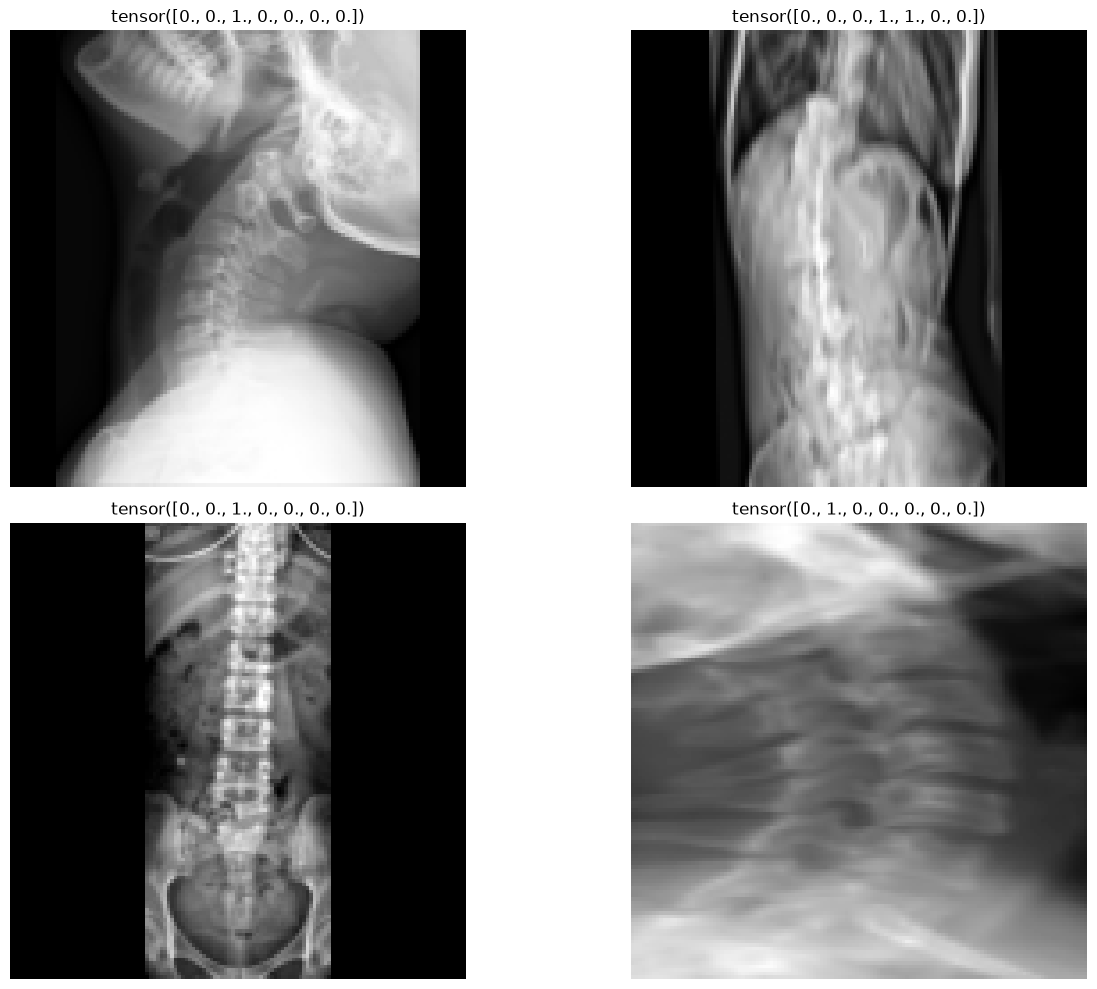

Epoch 1/2:   0%|          | 0/5 [00:00<?, ?it/s]d:\marchine_learning\Projet\medical_project\medical_env\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation Epoch 1:  80%|████████  | 4/5 [01:40<00:14, 15.00s/it, batch_loss=1.12]

[2026-07-29 19:38:54,751: INFO: accelerator: [RANK 0] The used dataset had no length, returning gathered tensors. You should drop the remainder yourself.]


Validation Epoch 1: 100%|██████████| 5/5 [01:40<00:00, 20.17s/it, batch_loss=1.12]


Epoch 1 - Train/Val Loss Ratio: 1.6359 / 1.4090
Epoch 1 - Detailed Validation Metrics: {'accuracy': 0.6142857074737549, 'f1_macro': 0.1646258533000946, 'recal_macro': 0.2655677795410156, 'loss': 1.4090198278427124}


Validation Epoch 2:  80%|████████  | 4/5 [01:27<00:12, 12.90s/it, batch_loss=1.15]

[2026-07-29 19:43:48,878: INFO: accelerator: [RANK 0] The used dataset had no length, returning gathered tensors. You should drop the remainder yourself.]


Validation Epoch 2: 100%|██████████| 5/5 [01:27<00:00, 17.57s/it, batch_loss=1.15]


Epoch 2 - Train/Val Loss Ratio: 1.7027 / 1.3929
Epoch 2 - Detailed Validation Metrics: {'accuracy': 0.5285714268684387, 'f1_macro': 0.21915709972381592, 'recal_macro': 0.22893773019313812, 'loss': 1.3928711414337158}


batch_step,▁▄▅█
epoch,▁▁██
train/accuracy,█▁
train/f1_macro,▁█
train/loss,▁█
train/loss_step,▁▆█▁
train/lr_scheduler,▁█
train/recal_macro,█▁
val/accuracy,█▁
val/f1_macro,▁█
+2,...


In [1]:
import sys
from pathlib import Path
sys.path.append("../")

from src.pipelines.cls_pipeline import ClsPipeline

config_path = r"D:\marchine_learning\Projet\medical_project\AI-Clinical-Imaging-Assistant\src\configs\classification\config_cls.yml"
clsPipeline = ClsPipeline(config_path)

clsPipeline.train()